# Part I: 1D Black Scholes Case

In [17]:
import numpy as np
import pandas as pd
import time

import matplotlib.pyplot as plt

from bsde_cfft_sv import BSDECFFT1D, bs_call_price, bs_call_delta, HestonBSDECFFT, GARCHDiffusionBSDECFFT
from bsde_cfft_sv._benchmarks import (
    garch_diffusion_approx_price,
    garch_diffusion_mc_milstein,
    garch_diffusion_pyfeng_delta_fd,
    garch_diffusion_pyfeng_mc_price,
    garch_diffusion_pyfeng_price,
    garch_diffusion_pyfeng_z_fd,
    heston_call_price,
    heston_delta_fd,
    heston_mc_milstein,
    heston_pyfeng_price,
    heston_z_fd,
)

In [19]:
S0, K, r, sigma, T = 100.0, 100.0, 0.01, 0.2, 1.0
L, n_steps, alpha = 10.0, 1000, -3.0

price_bs = bs_call_price(S0, K, r, sigma, T)
delta_bs = bs_call_delta(S0, K, r, sigma, T)

row_bs = []
for N in [1024,2048, 4096, 8192]:
    t0 = time.time()
    solver = BSDECFFT1D(r=r, mu=r, sigma=sigma, K=K, T=T, L=L, N=N, n_steps=n_steps, alpha=alpha)
    elapse = time.time() - t0
    price, delta = solver.price_at(S0)
    row_bs.append({
        "N": N,
        "price": price,
        "delta": delta,
        "time": elapse,
        "abs_price_error": abs(price_bs - price),
        "abs_delta_error": abs(delta_bs - delta)
    })

print("Black-Scholes Analytical Price", price_bs)
print("Analytical Delta", delta_bs)
df = pd.DataFrame(row_bs)
df

Black-Scholes Analytical Price 8.433318690109608
Analytical Delta 0.5596176923702425


,N,price,delta,time,abs_price_error,abs_delta_error
0,1024,8.431795,0.559619,0.002513,0.001524,0.000001
1,2048,8.432926,0.559623,0.000133,0.000392,0.000005
2,4096,8.433220,0.559623,0.000183,0.000098,0.000006
3,8192,8.433294,0.559623,0.000398,0.000025,0.000006


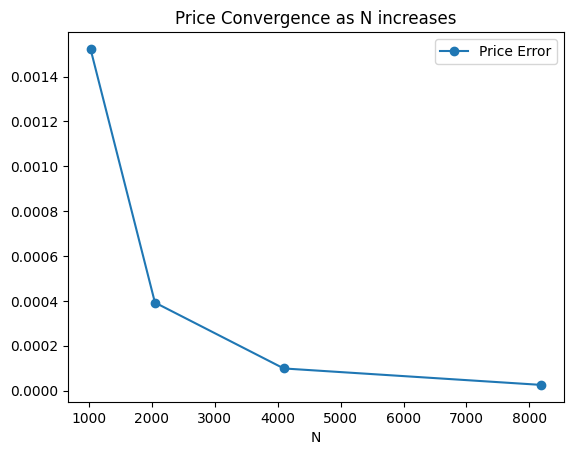

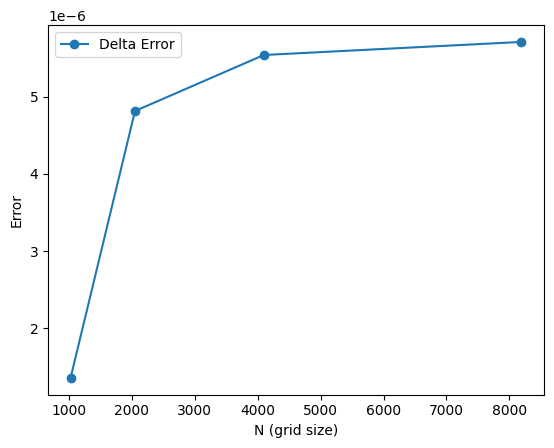

In [20]:




df.plot(x="N", y="abs_price_error", marker='o', label="Price Error")
plt.title("Price Convergence as N increases")
df.plot(x="N", y="abs_delta_error", marker='o', label="Delta Error")

plt.xlabel("N (grid size)")
plt.ylabel("Error")
plt.legend()
plt.show()

## Changing L Truncation Error

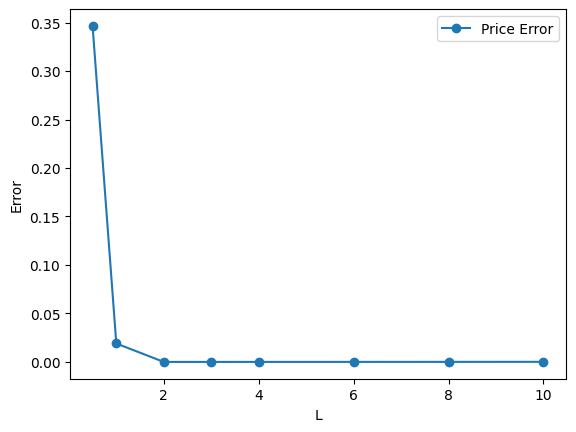

In [21]:
N = 4096

row_bs_L = []
for L in [0.5, 1, 2, 3, 4, 6, 8, 10]:
    t0 = time.time()
    solver = BSDECFFT1D(r=r, mu=r, sigma=sigma, K=K, T=T, L=L, N=N, n_steps=n_steps, alpha=alpha)
    elapse = time.time() - t0
    price, delta = solver.price_at(S0)
    row_bs_L.append({
        "L": L,
        "price": price,
        "delta": delta,
        "time": elapse,
        "abs_price_error": abs(price_bs - price),
        "abs_delta_error": abs(delta_bs - delta)
    })

import matplotlib.pyplot as plt

df_L = pd.DataFrame(row_bs_L)

df_L.plot(x="L", y="abs_price_error", marker='o', label="Price Error")

plt.xlabel("L")
plt.ylabel("Error")
plt.legend()
plt.show()

For small L, truncation error dominates because the log-price domain is too narrow.
Beyond a threshold (around L≈3), the domain is sufficiently large and truncation error becomes negligible relative to discretization error.

# Part II: 2D Heston Benchmark

## n_steps = 500

In [38]:
S0, K = 100.0, 100.0
r = 0.05
kappa, theta, xi, rho, V0, T = 2.0, 0.04, 0.3, -0.7, 0.04, 1.0

heston_ref_price = heston_call_price(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_ref_delta = heston_delta_fd(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_ref_zx, heston_ref_zv = heston_z_fd(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_pf_price = heston_pyfeng_price(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_mc_price, heston_mc_se = heston_mc_milstein(S0, K, r, kappa, theta, xi, rho, V0, T, n_paths=100000, n_steps=500)


# Different grid sizes to test
configs = [
    (32, 16),
    (64, 32),
    (96, 48),
    (128, 64),
    (160, 80),
]

rows = []

for Nx, Nv in configs:
    start = time.time()

    solver = HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T,
        Nx=Nx, Nv=Nv,
        Lx=10.0, Lv=0.25,
        n_steps=500,
        v_center=V0,
        alpha_x=-3.0,
    )

    price_num, delta_num, z_x_num, z_v_num = solver.price_delta_z_at(S0, V0)

    elapsed = time.time() - start

    rows.append({
        "Nx": Nx,
        "Nv": Nv,
        "grid_points": Nx * Nv,
        "n_steps": 500,
        "price": price_num,
        "abs_price_error": abs(price_num - heston_ref_price),
        "delta": delta_num,
        "z_x": z_x_num,
        "abs_zx_error": abs(z_x_num - heston_ref_zx),
        "z_v": z_v_num,
        "abs_zv_error": abs(z_v_num - heston_ref_zv),
        "time_s": elapsed
    })

df = pd.DataFrame(rows)

In [39]:
df

,Nx,Nv,grid_points,n_steps,price,abs_price_error,delta,z_x,abs_zx_error,z_v,abs_zv_error,time_s
0,32,16,512,500,8.651154,1.743065,0.692226,12.265650,0.075254,1.542131,0.138092,0.111589
1,64,32,2048,500,10.243828,0.150391,0.681494,12.147834,0.042562,1.505821,0.174402,0.206626
2,96,48,4608,500,10.343438,0.050781,0.685698,12.153902,0.036494,1.584352,0.095871,0.702724
3,128,64,8192,500,10.368312,0.025907,0.687952,12.163467,0.026929,1.624865,0.055358,1.128091
4,160,80,12800,500,10.378931,0.015288,0.689178,12.172251,0.018145,1.641762,0.038461,1.051970


## n_steps = 1100

In [41]:
S0, K = 100.0, 100.0
r = 0.05
kappa, theta, xi, rho, V0, T = 2.0, 0.04, 0.3, -0.7, 0.04, 1.0

heston_ref_price = heston_call_price(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_ref_delta = heston_delta_fd(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_ref_zx, heston_ref_zv = heston_z_fd(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_pf_price = heston_pyfeng_price(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_mc_price, heston_mc_se = heston_mc_milstein(S0, K, r, kappa, theta, xi, rho, V0, T, n_paths=100000, n_steps=500)


# Different grid sizes to test
configs = [
    (32, 16),
    (64, 32),
    (96, 48),
    (128, 64),
    (160, 80),
]

rows = []

for Nx, Nv in configs:
    start = time.time()

    solver = HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T,
        Nx=Nx, Nv=Nv,
        Lx=10.0, Lv=0.25,
        n_steps=1100,
        v_center=V0,
        alpha_x=-3.0,
    )

    price_num, delta_num, z_x_num, z_v_num = solver.price_delta_z_at(S0, V0)

    elapsed = time.time() - start

    rows.append({
        "Nx": Nx,
        "Nv": Nv,
        "grid_points": Nx * Nv,
        "n_steps": 1100,
        "price": price_num,
        "abs_price_error": abs(price_num - heston_ref_price),
        "delta": delta_num,
        "z_x": z_x_num,
        "abs_zx_error": abs(z_x_num - heston_ref_zx),
        "z_v": z_v_num,
        "abs_zv_error": abs(z_v_num - heston_ref_zv),
        "time_s": elapsed
    })

df_1100 = pd.DataFrame(rows)

In [42]:
df_1100

,Nx,Nv,grid_points,n_steps,price,abs_price_error,delta,z_x,abs_zx_error,z_v,abs_zv_error,time_s
0,32,16,512,1100,8.669577,1.724641,0.692255,12.286348,0.095952,1.521566,0.158657,0.243191
1,64,32,2048,1100,10.287373,0.106846,0.681236,12.206639,0.016243,1.440551,0.239673,0.466218
2,96,48,4608,1100,10.374206,0.020012,0.684924,12.178109,0.012287,1.543851,0.136372,1.638136
3,128,64,8192,1100,10.381532,0.012687,0.687417,12.170476,0.019920,1.606834,0.073389,2.607005
4,160,80,12800,1100,10.384226,0.009992,0.688907,12.175802,0.014594,1.632607,0.047616,2.479538


## Plots

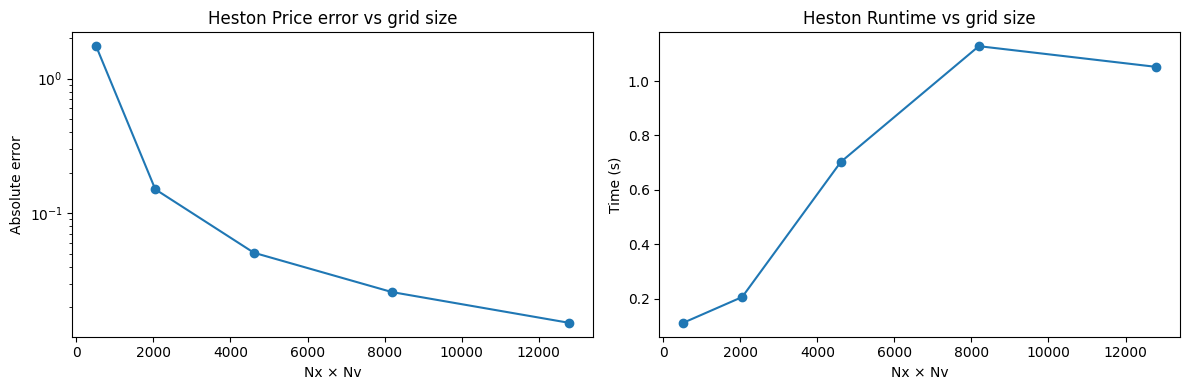

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Error vs grid size
axes[0].plot(df["grid_points"], df["abs_price_error"], marker="o")
axes[0].set_title("Heston Price error vs grid size")
axes[0].set_xlabel("Nx × Nv")
axes[0].set_ylabel("Absolute error")
axes[0].set_yscale("log")

# Time vs grid size
axes[1].plot(df["grid_points"], df["time_s"], marker="o")
axes[1].set_title("Heston Runtime vs grid size")
axes[1].set_xlabel("Nx × Nv")
axes[1].set_ylabel("Time (s)")

plt.tight_layout()
plt.show()

The numerical method converges to the true solution as grid resolution increases, and here is the accuracy vs cost tradeoff

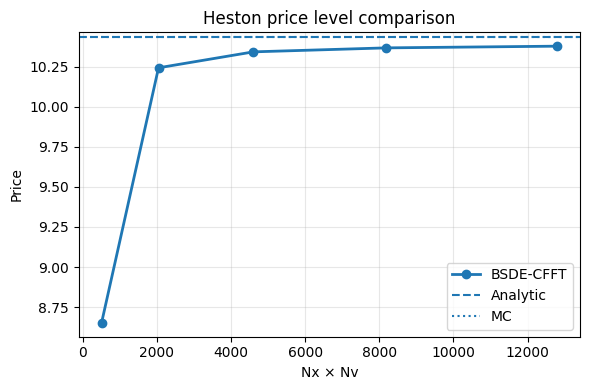

In [44]:
plt.figure(figsize=(6, 4))

plt.plot(df["grid_points"], df["price"], marker="o", linewidth=2, label="BSDE-CFFT")
plt.axhline(ref_price, linestyle="--", label="Analytic")
plt.axhline(heston_mc_price, linestyle=":", label="MC")

plt.title("Heston price level comparison")
plt.xlabel("Nx × Nv")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Part III: 2D GARCH Diffusion 

## Case rho = 0

In [45]:
S0, K = 100.0, 100.0
r, mu, a, b, c, V0, T = 0.05, 0.05, 2.0, 0.04, 0.4, 0.04, 1.0

garch_configs = [
    (32, 16, 0.32, 200),
    (64, 32, 0.32, 500),
    (96, 48, 0.32, 700),
    (128, 64, 0.32, 900),
    (160, 80, 0.32, 1100),
]

rho0 = 0.0
garch_price_approx, sigma_eff = garch_diffusion_approx_price(S0, K, r, mu, a, b, c, V0, T)
garch_pf_price = garch_diffusion_pyfeng_price(S0, K, r, a, b, c, V0, T)
garch_pf_delta = garch_diffusion_pyfeng_delta_fd(S0, K, r, a, b, c, V0, T)
garch_pf_z = garch_diffusion_pyfeng_z_fd(S0, K, r, a, b, c, rho0, V0, T)
garch_mc_price_rho0, garch_mc_se_rho0 = garch_diffusion_mc_milstein(S0, K, r, mu, a, b, c, rho0, V0, T, n_paths=100000, n_steps=500)
garch_pf_mc_rho0 = garch_diffusion_pyfeng_mc_price(S0, K, r, a, b, c, rho0, V0, T, n_paths=100000, n_steps=500)

garch_rows_rho0 = []
for Nx, Nv, Lv, n_steps in garch_configs:
    t0 = time.time()
    solver = GARCHDiffusionBSDECFFT(
        r=r, mu=mu, a=a, b=b, c=c, rho=rho0,
        K=K, T=T, Nx=Nx, Nv=Nv, Lx=10.0, Lv=Lv,
        n_steps=n_steps, v_center=V0, alpha_x=-3.0,
    )
    price_num, delta_num, z_x_num, z_v_num = solver.price_delta_z_at(S0, V0)
    elapsed = time.time() - t0
    garch_rows_rho0.append({
        "Nx": Nx,
        "Nv": Nv,
        "grid_points": Nx * Nv,
        "Lv": Lv,
        "n_steps": n_steps,
        "price": price_num,
        "abs_price_error_vs_pyfeng": abs(price_num - garch_pf_price) if garch_pf_price is not None else np.nan,
        "delta": delta_num,
        "z_x": z_x_num,
        "abs_zx_error": abs(z_x_num - garch_pf_z[0]) if garch_pf_z is not None else np.nan,
        "z_v": z_v_num,
        "abs_zv_error": abs(z_v_num - garch_pf_z[1]) if garch_pf_z is not None else np.nan,
        "time_s": elapsed,
    })

garch_df_rho0 = pd.DataFrame(garch_rows_rho0)
print(f"Mean-var BS approx = {garch_price_approx:.6f} with sigma_eff = {sigma_eff:.4f}")
print(f"PyFeng BA order 2 price = {garch_pf_price:.6f}")
print(f"PyFeng delta ≈ {garch_pf_delta:.6f}")
print(f"PyFeng Z references: Zx ≈ {garch_pf_z[0]:.6f}, Zv ≈ {garch_pf_z[1]:.6f}")
print(f"Monte Carlo Milstein = {garch_mc_price_rho0:.6f} ± {2*garch_mc_se_rho0:.6f}")
print(f"PyFeng MC Milstein = {garch_pf_mc_rho0:.6f}")
garch_df_rho0

Mean-var BS approx = 10.450584 with sigma_eff = 0.2000
PyFeng BA order 2 price = 10.437383
PyFeng delta ≈ 0.637278
PyFeng Z references: Zx ≈ 12.745559, Zv ≈ 0.645984
Monte Carlo Milstein = 10.483523 ± 0.093495
PyFeng MC Milstein = 10.436958


,Nx,Nv,grid_points,Lv,n_steps,price,abs_price_error_vs_pyfeng,delta,z_x,abs_zx_error,z_v,abs_zv_error,time_s
0,32,16,512,0.32,200,8.902374,1.535009,0.666983,13.339373,0.593814,-0.191149,0.837133,0.046180
1,64,32,2048,0.32,500,10.931110,0.493728,0.642254,12.844966,0.099407,-0.977295,1.623279,0.216415
2,96,48,4608,0.32,700,10.590470,0.153088,0.638774,12.775394,0.029834,0.383826,0.262158,0.998572
3,128,64,8192,0.32,900,10.425887,0.011496,0.638432,12.768576,0.023017,0.617802,0.028182,2.015693
4,160,80,12800,0.32,1100,10.434585,0.002798,0.637992,12.759792,0.014232,0.589472,0.056512,2.235237


# Case rho = -0.5

In [46]:
rho_corr = -0.5
garch_mc_price_corr, garch_mc_se_corr = garch_diffusion_mc_milstein(S0, K, r, mu, a, b, c, rho_corr, V0, T, n_paths=100000, n_steps=500)
garch_pf_mc_corr = garch_diffusion_pyfeng_mc_price(S0, K, r, a, b, c, rho_corr, V0, T, n_paths=100000, n_steps=500)

garch_rows_corr = []
for Nx, Nv, Lv, n_steps in garch_configs:
    t0 = time.time()
    solver = GARCHDiffusionBSDECFFT(
        r=r, mu=mu, a=a, b=b, c=c, rho=rho_corr,
        K=K, T=T, Nx=Nx, Nv=Nv, Lx=10.0, Lv=Lv,
        n_steps=n_steps, v_center=V0, alpha_x=-3.0,
    )
    price_num, delta_num, z_x_num, z_v_num = solver.price_delta_z_at(S0, V0)
    elapsed = time.time() - t0
    garch_rows_corr.append({
        "Nx": Nx,
        "Nv": Nv,
        "grid_points": Nx * Nv,
        "price": price_num,
        "abs_price_error_vs_mc": abs(price_num - garch_mc_price_corr),
        "z_x": z_x_num,
        "z_v": z_v_num,
        "time_s": elapsed,
    })

garch_df_corr = pd.DataFrame(garch_rows_corr)
print(f"Correlated-case Monte Carlo = {garch_mc_price_corr:.6f} ± {2*garch_mc_se_corr:.6f}")
print(f"Correlated-case PyFeng MC = {garch_pf_mc_corr:.6f}")
garch_df_corr

Correlated-case Monte Carlo = 10.506790 ± 0.090167
Correlated-case PyFeng MC = 10.465541


,Nx,Nv,grid_points,price,abs_price_error_vs_mc,z_x,z_v,time_s
0,32,16,512,8.898683,1.608107,13.392884,-0.193488,0.046154
1,64,32,2048,10.947886,0.441096,13.199412,-0.986741,0.220889
2,96,48,4608,10.666436,0.159646,12.755577,0.260990,1.085152
3,128,64,8192,10.455351,0.051439,12.644348,0.536376,2.151675
4,160,80,12800,10.456805,0.049985,12.645065,0.506802,2.336820


## Plots

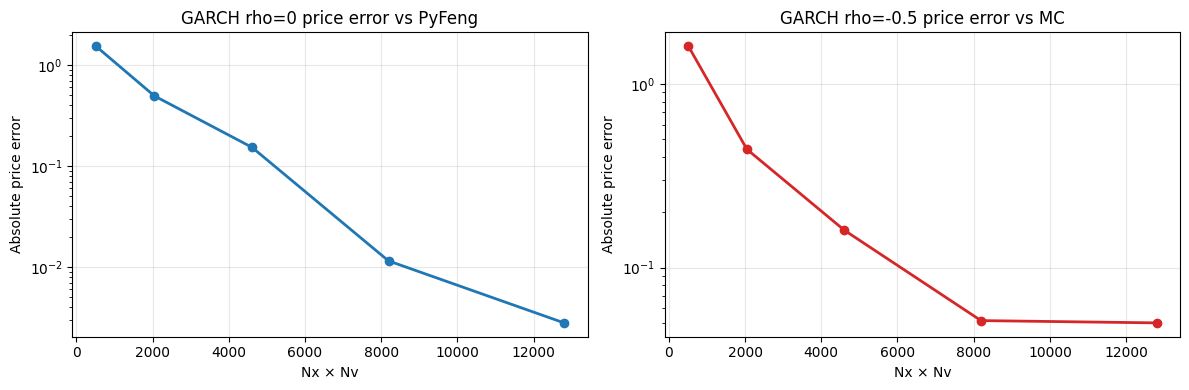

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(garch_df_rho0["grid_points"], garch_df_rho0["abs_price_error_vs_pyfeng"], marker="o", linewidth=2)
axes[0].set_title("GARCH rho=0 price error vs PyFeng")
axes[0].set_xlabel("Nx × Nv")
axes[0].set_ylabel("Absolute price error")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].plot(garch_df_corr["grid_points"], garch_df_corr["abs_price_error_vs_mc"], marker="o", linewidth=2, color="tab:red")
axes[1].set_title("GARCH rho=-0.5 price error vs MC")
axes[1].set_xlabel("Nx × Nv")
axes[1].set_ylabel("Absolute price error")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

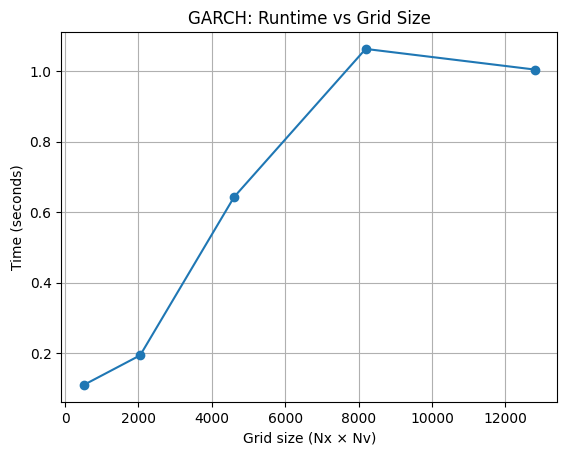

In [32]:
plt.plot(df["grid_points"], df["time_s"], marker="o")
plt.xlabel("Grid size (Nx × Nv)")
plt.ylabel("Time (seconds)")
plt.title("GARCH: Runtime vs Grid Size")
plt.grid(True)
plt.show()

# Part IV: Sensitivity Analysis

In [47]:
def run_sensitivity(param_name, values, solver_builder, ref_price):
    rows = []
    
    for val in values:
        t0 = time.time()
        
        solver = solver_builder(val)
        price, _ = solver.price_at(S0, V0)
        
        rows.append({
            param_name: val,
            "price": price,
            "abs_price_error": abs(price - ref_price),
            "time_s": time.time() - t0
        })
    
    return pd.DataFrame(rows)

In [48]:
S0, K, r, V0, T = 100.0, 100.0, 0.05, 0.04, 1.0
kappa, theta, xi, rho = 2.0, 0.04, 0.3, -0.7
rho0 = 0.0

lv_df = run_sensitivity(
    "Lv",
    [0.15, 0.20, 0.25, 0.30, 0.40],
    lambda Lv: HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T, Nx=96, Nv=48, Lx=10.0, Lv=Lv,
        n_steps=700, v_center=V0, alpha_x=-3.0,
    ),
    heston_call_price(S0, K, r, kappa, theta, xi, rho, V0, T)
)

boundary_df = run_sensitivity(
    "v_boundary",
    ["none", "neumann"],
    lambda vb: HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T, Nx=96, Nv=48, Lx=10.0, Lv=0.20,
        n_steps=700, v_center=V0, alpha_x=-3.0,
        v_boundary=vb,
    ),
   heston_call_price(S0, K, r, kappa, theta, xi, rho, V0, T)
)



alpha_df = run_sensitivity(
    "alpha_x",
    [-2.5, -3.0, -3.5],
    lambda alpha_x: GARCHDiffusionBSDECFFT(
        r=r, mu=mu, a=a, b=b, c=c, rho=rho0,
        K=K, T=T, Nx=96, Nv=48, Lx=10.0, Lv=0.32,
        n_steps=700, v_center=V0, alpha_x=alpha_x,
    ),
    garch_diffusion_pyfeng_price(S0, K, r, a, b, c, V0, T)
)

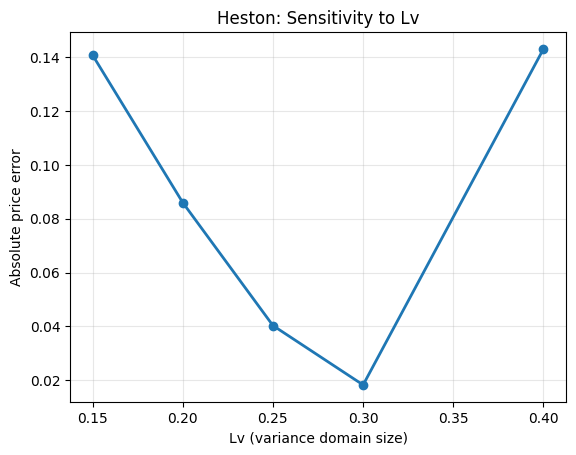

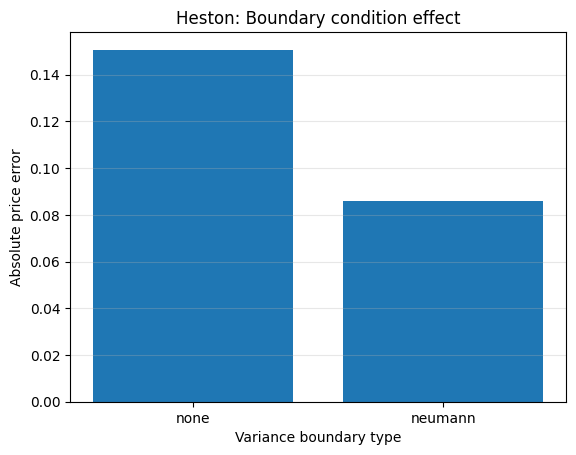

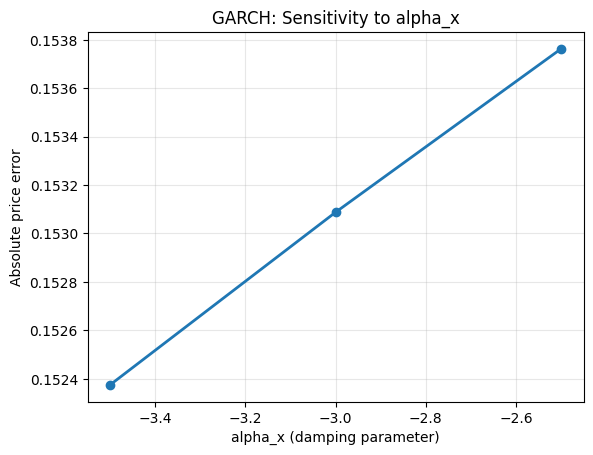

In [49]:
import matplotlib.pyplot as plt

# --- Lv sensitivity ---
plt.figure()
plt.plot(lv_df["Lv"], lv_df["abs_price_error"], marker="o", linewidth=2)
plt.title("Heston: Sensitivity to Lv")
plt.xlabel("Lv (variance domain size)")
plt.ylabel("Absolute price error")
plt.grid(True, alpha=0.3)
plt.show()


# --- Boundary condition sensitivity ---
plt.figure()
plt.bar(boundary_df["v_boundary"], boundary_df["abs_price_error"])
plt.title("Heston: Boundary condition effect")
plt.xlabel("Variance boundary type")
plt.ylabel("Absolute price error")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


# --- Alpha sensitivity ---
plt.figure()
plt.plot(alpha_df["alpha_x"], alpha_df["abs_price_error"], marker="o", linewidth=2)
plt.title("GARCH: Sensitivity to alpha_x")
plt.xlabel("alpha_x (damping parameter)")
plt.ylabel("Absolute price error")
plt.grid(True, alpha=0.3)
plt.show()

## Brief Observations

The results show that increasing the grid size improves pricing accuracy, as the absolute error decreases steadily with (N). This is consistent with convergence of the numerical scheme.

The truncation parameter (L) also affects accuracy: values that are too small introduce truncation error, while overly large values can reduce efficiency without improving results. An intermediate choice provides the best balance.